**Data Preprocessing**

In [1]:
!pip install scanpy
!pip install torch
!pip install mygene -q
import scanpy as sc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn.functional as F
import json
import pickle
import torch.nn as nn
import torch.optim as optim


import mygene

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

In [2]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('Setup complete!')

Device: cuda
Setup complete!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_DIR = '/content/drive/MyDrive/DL_Project_files/data/output'

In [6]:
SPLITS_DIR = '/content/drive/MyDrive/DL_Project_files/data/splits_norman/'

In [7]:
OUTPUT_DIR   = '/content/drive/MyDrive/DL_Project_files/data/output'

In [8]:
adata = sc.read_h5ad(f'{DATA_DIR}/norman.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


In [9]:
conditions = list(adata.obs['condition'].unique())
single_perts = [c for c in conditions if '+ctrl' in c or 'ctrl+' in c]
dual_perts = [c for c in conditions if '+' in c and 'ctrl' not in c]
n_ctrl_cells = (adata.obs['control'] == 1).sum()

In [10]:
print(f"""
PERTURBATION STRUCTURE
Control cells:             {n_ctrl_cells:,} cells (baseline, no perturbation)
Single-gene perturbations: {len(single_perts)} conditions (e.g., "CBL+ctrl")
Dual-gene perturbations:   {len(dual_perts)} conditions (e.g., "CBL+UBASH3B")

Examples:
  Single: {single_perts[:3]}
  Dual:   {dual_perts[:3]}
""")


PERTURBATION STRUCTURE
Control cells:             7,353 cells (baseline, no perturbation)
Single-gene perturbations: 152 conditions (e.g., "CBL+ctrl")
Dual-gene perturbations:   131 conditions (e.g., "CBL+UBASH3B")

Examples:
  Single: ['TSC22D1+ctrl', 'MAML2+ctrl', 'ctrl+CEBPE']
  Dual:   ['KLF1+MAP2K6', 'CEBPE+RUNX1T1', 'CBL+PTPN9']



In [11]:
print("X dtype:", adata.X.dtype)
print("X shape:", adata.X.shape)
print("X min/max:", adata.X.min(), adata.X.max())
print("Is sparse:", hasattr(adata.X, 'toarray'))
print()

X dtype: float32
X shape: (91205, 5045)
X min/max: 0.0 8.90458
Is sparse: True



In [12]:
for split_type in ['simulation', 'combo_seen0', 'combo_seen1', 'combo_seen2']:
    try:
        masks = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')
        print(f"split_{split_type}:")
        print(f"  columns: {masks.columns.tolist()}")
        print(f"  sizes:   {masks.sum().to_dict()}")
        print()
    except FileNotFoundError:
        print(f"split_{split_type}.csv — NOT FOUND, check filename")

split_simulation:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 49849, 'val': 10754, 'test': 28754}

split_combo_seen0:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 65564, 'val': 5025, 'test': 5830}

split_combo_seen1:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 65564, 'val': 12171, 'test': 11622}

split_combo_seen2:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 82784, 'val': 3575, 'test': 2998}



In [13]:
masks = pd.read_csv(f'{SPLITS_DIR}split_simulation.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1  False   True  False
2   True  False  False
3   True  False  False
4   True  False  False
5   True  False  False
6   True  False  False
7  False  False   True
8  False   True  False
9   True  False  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [14]:
masks = pd.read_csv(f'{SPLITS_DIR}split_combo_seen0.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1   True  False  False
2   True  False  False
3  False  False  False
4   True  False  False
5  False   True  False
6   True  False  False
7  False  False  False
8   True  False  False
9  False  False  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [15]:
masks = pd.read_csv(f'{SPLITS_DIR}split_combo_seen1.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1   True  False  False
2   True  False  False
3  False   True  False
4   True  False  False
5  False   True  False
6   True  False  False
7  False  False   True
8   True  False  False
9  False   True  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [16]:
masks = pd.read_csv(f'{SPLITS_DIR}split_combo_seen2.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1  False   True  False
2   True  False  False
3  False   True  False
4   True  False  False
5   True  False  False
6   True  False  False
7   True  False  False
8   True  False  False
9   True  False  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [17]:
results = {}

for split_type in ['simulation', 'combo_seen2', 'combo_seen1', 'combo_seen0']:
    masks = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')

    train_adata_s = adata[masks['train'].values]
    val_adata_s   = adata[masks['val'].values]
    test_adata_s  = adata[masks['test'].values]

    print(f"\n{'='*50}")
    print(f"Split: {split_type}")
    print(f"  Train: {train_adata_s.n_obs:,} cells")
    print(f"  Val:   {val_adata_s.n_obs:,} cells")
    print(f"  Test:  {test_adata_s.n_obs:,} cells")

    results[split_type] = {
        'train': train_adata_s,
        'val':   val_adata_s,
        'test':  test_adata_s
    }

# ── FIX (Bug 1): Explicitly choose the working split ──────────────────────────
# Previously, train_adata/val_adata/test_adata were leaked from the last loop
# iteration (combo_seen0), causing all downstream code to silently use the wrong split.
# Now we pick the split we actually want before computing ctrl_mean and building datasets.
ACTIVE_SPLIT = 'combo_seen2'   # change to 'simulation', 'combo_seen1', etc. as needed

masks       = pd.read_csv(f'{SPLITS_DIR}split_{ACTIVE_SPLIT}.csv')
train_adata = adata[masks['train'].values]
val_adata   = adata[masks['val'].values]
test_adata  = adata[masks['test'].values]

print(f"\nActive split: {ACTIVE_SPLIT}")
print(f"  Train: {train_adata.n_obs:,}  Val: {val_adata.n_obs:,}  Test: {test_adata.n_obs:,}")



Split: simulation
  Train: 49,849 cells
  Val:   10,754 cells
  Test:  28,754 cells

Split: combo_seen2
  Train: 82,784 cells
  Val:   3,575 cells
  Test:  2,998 cells

Split: combo_seen1
  Train: 65,564 cells
  Val:   12,171 cells
  Test:  11,622 cells

Split: combo_seen0
  Train: 65,564 cells
  Val:   5,025 cells
  Test:  5,830 cells

Active split: combo_seen2
  Train: 82,784  Val: 3,575  Test: 2,998


# STEP 1 — PREPROCESSING


## 1. Verify Expression Matrix

In [18]:
# Check what adata.X contains
X_sample = adata.X[:200]
if hasattr(X_sample, 'toarray'):
    X_sample = X_sample.toarray()

print('Expression matrix (adata.X):')
print(f'  dtype:    {adata.X.dtype}')
print(f'  is sparse:{hasattr(adata.X, "toarray")}')
print(f'  min:      {X_sample.min():.3f}')
print(f'  max:      {X_sample.max():.3f}')
print(f'  mean:     {X_sample.mean():.3f}')
print(f'  sparsity: {(X_sample == 0).mean()*100:.1f}% zeros')
print()
print('  → Values between 0-10 = log-normalised ✓')
print('  → High sparsity (>80%) is normal for scRNA-seq ✓')

Expression matrix (adata.X):
  dtype:    float32
  is sparse:True
  min:      0.000
  max:      7.182
  mean:     0.106
  sparsity: 92.0% zeros

  → Values between 0-10 = log-normalised ✓
  → High sparsity (>80%) is normal for scRNA-seq ✓


In [19]:
import matplotlib.pyplot as plt


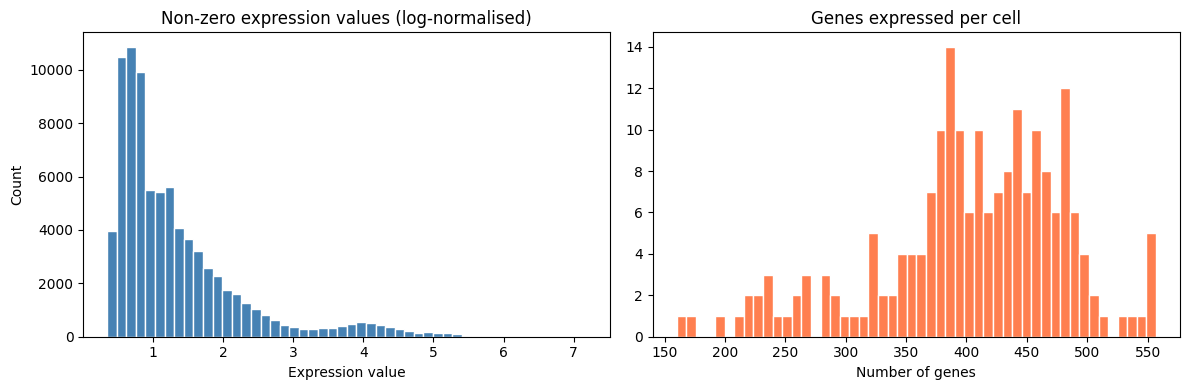

In [20]:
# Plot expression distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nonzero = X_sample[X_sample > 0].flatten()
axes[0].hist(nonzero, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Non-zero expression values (log-normalised)')
axes[0].set_xlabel('Expression value')
axes[0].set_ylabel('Count')

genes_per_cell = (X_sample > 0).sum(axis=1)
axes[1].hist(genes_per_cell, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Genes expressed per cell')
axes[1].set_xlabel('Number of genes')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/expression_distribution.png', dpi=100)
plt.show()

## 2. Compute Control Mean (Basal State)

In [21]:
# Control mean = average expression of unperturbed cells
# This is the 'basal state' — what a cell looks like with no perturbation
# IMPORTANT: compute from TRAIN controls only, never from val/test

ctrl_train_mask = train_adata.obs['control'] == 1
ctrl_train      = train_adata[ctrl_train_mask]

ctrl_X = ctrl_train.X
if hasattr(ctrl_X, 'toarray'):
    ctrl_X = ctrl_X.toarray()

ctrl_mean        = ctrl_X.mean(axis=0)               # shape: (5045,)
ctrl_mean_tensor = torch.tensor(ctrl_mean, dtype=torch.float32)

print(f'Control cells in train: {ctrl_train_mask.sum():,}')
print(f'ctrl_mean shape:        {ctrl_mean.shape}')
print(f'ctrl_mean min/max:      {ctrl_mean.min():.3f} / {ctrl_mean.max():.3f}')

# Save for later use
np.save(f'{OUTPUT_DIR}/ctrl_mean.npy', ctrl_mean)
print('\nSaved ctrl_mean.npy to Drive ✓')

Control cells in train: 7,353
ctrl_mean shape:        (5045,)
ctrl_mean min/max:      0.000 / 5.144

Saved ctrl_mean.npy to Drive ✓


## 3. Extract Perturbed Gene List

In [22]:
def parse_condition(cond):
    """Extract gene names from condition string.
    'CBL+ctrl'     → ['CBL']
    'CBL+UBASH3B'  → ['CBL', 'UBASH3B']
    'ctrl'         → []
    """
    parts = cond.split('+')
    return [p for p in parts if p != 'ctrl']


In [23]:
# Get all unique perturbed genes
all_perturbed_genes = set()
for cond in adata.obs['condition'].unique():
    for gene in parse_condition(cond):
        all_perturbed_genes.add(gene)

all_perturbed_genes = sorted(all_perturbed_genes)
print(f'Unique perturbed genes: {len(all_perturbed_genes)}')
print(f'First 15: {all_perturbed_genes[:15]}')


Unique perturbed genes: 105
First 15: ['AHR', 'ARID1A', 'ARRDC3', 'ATL1', 'BAK1', 'BCL2L11', 'BCORL1', 'BPGM', 'C19orf26', 'C3orf72', 'CBFA2T3', 'CBL', 'CDKN1A', 'CDKN1B', 'CDKN1C']


In [24]:
# Build condition → index mapping (needed for model)
all_conditions  = sorted(adata.obs['condition'].unique())
cond2idx        = {c: i for i, c in enumerate(all_conditions)}
n_conditions    = len(all_conditions)
print(f'\nTotal unique conditions: {n_conditions}')


Total unique conditions: 284


In [25]:
# Save both
with open(f'{OUTPUT_DIR}/perturbed_genes.json', 'w') as f:
    json.dump(all_perturbed_genes, f, indent=2)

with open(f'{OUTPUT_DIR}/cond2idx.json', 'w') as f:
    json.dump(cond2idx, f, indent=2)

## 4. Visualise Perturbation Distribution

In [26]:
# How many cells per perturbation condition?
# pert_counts = adata.obs['condition'].value_counts()

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Top 30 conditions by cell count
# top30 = pert_counts.head(30)
# colors = ['#5782F0' if 'ctrl' in c else
#           '#EDEF51' if '+ctrl' in c or 'ctrl+' in c else
#           '#FC5454' for c in top30.index]
# axes[0].barh(range(30), top30.values, color=colors)
# axes[0].set_yticks(range(30))
# axes[0].set_yticklabels(top30.index, fontsize=7)
# axes[0].set_title('Top 30 conditions by cell count')
# axes[0].set_xlabel('Number of cells')

# from matplotlib.patches import Patch
# legend = [
#     Patch(color="#5782F0", label='Control'),
#     Patch(color="#EDEF51", label='Single pert'),
#     Patch(color="#FC5454", label='Dual pert'),
# ]
# axes[0].legend(handles=legend, fontsize=8)


# # Distribution of cells per condition
# axes[1].hist(pert_counts.values, bins=40, color='steelblue', edgecolor='white')
# axes[1].set_title('Distribution: cells per condition')
# axes[1].set_xlabel('Cells per condition')
# axes[1].set_ylabel('Number of conditions')
# axes[1].axvline(pert_counts.median(), color='red',
#                 linestyle='--', label=f'Median: {pert_counts.median():.0f}')
# axes[1].legend()

# plt.tight_layout()
# plt.savefig(f'{OUPUT_DIR}/perturbation_distribution.png', dpi=100)
# plt.show()
# print(f'Median cells per condition: {pert_counts.median():.0f}')


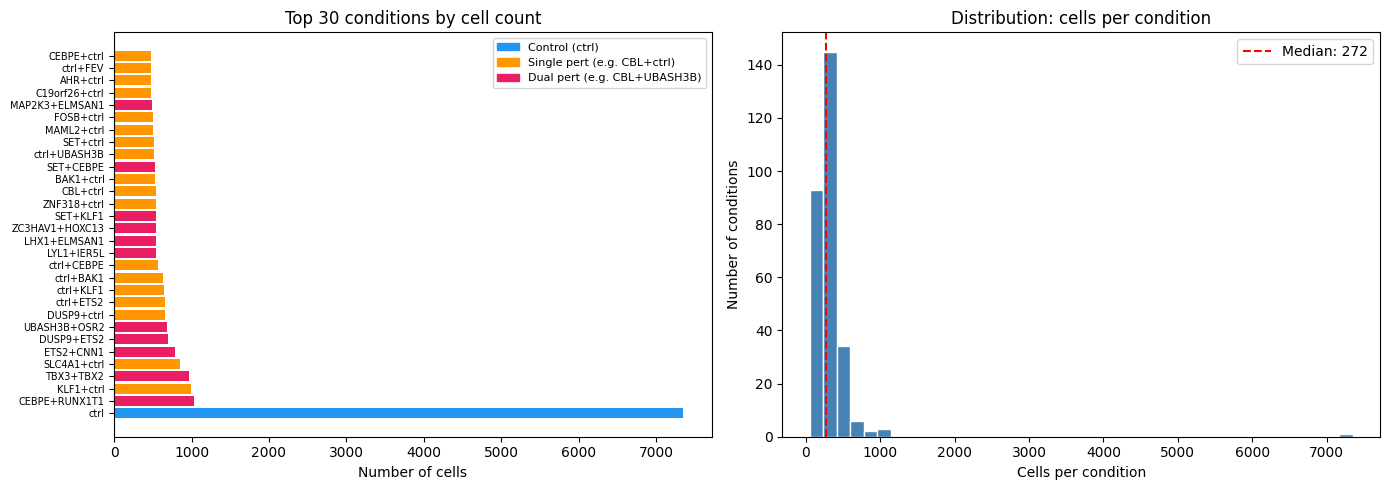

In [27]:
def get_color(condition):
    if condition == 'ctrl':
        return '#2196F3'          # pure control → blue
    elif '+ctrl' in condition or 'ctrl+' in condition:
        return '#FF9800'          # single pert → orange
    else:
        return '#E91E63'          # dual pert → pink/red
pert_counts = adata.obs['condition'].value_counts()
top30 = pert_counts.head(30)
colors = [get_color(c) for c in top30.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(30), top30.values, color=colors)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top30.index, fontsize=7)
axes[0].set_title('Top 30 conditions by cell count')
axes[0].set_xlabel('Number of cells')

from matplotlib.patches import Patch
legend = [
    Patch(color='#2196F3', label='Control (ctrl)'),
    Patch(color='#FF9800', label='Single pert (e.g. CBL+ctrl)'),
    Patch(color='#E91E63', label='Dual pert (e.g. CBL+UBASH3B)'),
]
axes[0].legend(handles=legend, fontsize=8)

#Distribution of cells per condition
axes[1].hist(pert_counts.values, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution: cells per condition')
axes[1].set_xlabel('Cells per condition')
axes[1].set_ylabel('Number of conditions')
axes[1].axvline(pert_counts.median(), color='red',
                linestyle='--', label=f'Median: {pert_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/perturbation_distribution.png', dpi=100)
plt.show()

# STEP 2 — BUILD PYTORCH DATASET
### Wrap the AnnData splits into DataLoaders the model can consume

## NormanDataset Class

In [28]:
class NormanDataset(Dataset):
    """
    Wraps a split of the Norman AnnData into a PyTorch Dataset.

    Each item returns:
      x_perturbed  → actual post-perturbation expression  (n_genes,)
      x_basal      → control mean expression              (n_genes,)
      condition    → condition string e.g. 'CBL+ctrl'
      cond_idx     → integer index of the condition
      is_control   → 1 if this is a control cell, else 0
    """
    def __init__(self, adata_subset, ctrl_mean_tensor, cond2idx):
        # Convert sparse matrix to dense numpy
        X = adata_subset.X
        if hasattr(X, 'toarray'):
            X = X.toarray()

        self.X          = torch.tensor(X, dtype=torch.float32)
        self.ctrl_mean  = ctrl_mean_tensor
        self.conditions = adata_subset.obs['condition'].values
        self.is_control = adata_subset.obs['control'].values
        self.cond_idx   = torch.tensor(
            [cond2idx[c] for c in self.conditions], dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'x_perturbed': self.X[idx],
            'x_basal':     self.ctrl_mean,
            'condition':   self.conditions[idx],
            'cond_idx':    self.cond_idx[idx],
            'is_control':  int(self.is_control[idx]),
        }



In [29]:
# Build datasets for all 3 splits
train_ds = NormanDataset(train_adata, ctrl_mean_tensor, cond2idx)
val_ds   = NormanDataset(val_adata,   ctrl_mean_tensor, cond2idx)
test_ds  = NormanDataset(test_adata,  ctrl_mean_tensor, cond2idx)

# Build DataLoaders
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
batch = next(iter(train_loader))
print('DataLoader sanity check:')
print(f"  x_perturbed: {batch['x_perturbed'].shape}")
print(f"  x_basal:     {batch['x_basal'].shape}")
print(f"  cond_idx:    {batch['cond_idx'].shape}")
print(f"  condition:   {batch['condition'][:3]}")
print(f"  is_control:  {batch['is_control'][:5].tolist()}")
print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

DataLoader sanity check:
  x_perturbed: torch.Size([256, 5045])
  x_basal:     torch.Size([256, 5045])
  cond_idx:    torch.Size([256])
  condition:   ['FOXF1+ctrl', 'ctrl+MEIS1', 'ctrl']
  is_control:  [0, 0, 1, 1, 0]

Train batches: 324
Val batches:   14
Test batches:  12


# STEP 3 — LLM GENE EMBEDDINGS
### Generate a 768-dim semantic vector for each perturbed gene
### This is the 'semantic bridge' — the key novelty of the project

In [30]:
from transformers import AutoTokenizer, AutoModel

mg = mygene.MyGeneInfo()

def fetch_gene_descriptions(gene_list):
    descriptions = {}
    for i in range(0, len(gene_list), 50):
        batch = gene_list[i:i+50]
        try:
            results = mg.querymany(
                batch,
                scopes='symbol',
                fields='summary,name',
                species='human',
                returnall=False
            )
            for r in results:
                gene    = r.get('query', '')
                summary = r.get('summary', '')
                name    = r.get('name', '')
                if summary:
                    descriptions[gene] = f"{gene} ({name}): {summary}"
                elif name:
                    descriptions[gene] = f"{gene} encodes {name}, involved in cellular regulation."
                else:
                    descriptions[gene] = f"{gene} is a gene involved in cellular signaling."
        except Exception as e:
            print(f"Batch failed: {e}")
    return descriptions

# Fetch for ALL 105 Norman genes — no hardcoding needed
print(f"Fetching descriptions for {len(all_perturbed_genes)} genes...")
real_descriptions = fetch_gene_descriptions(all_perturbed_genes)

INFO:biothings.client:querying 1-50 ...


Fetching descriptions for 105 genes...


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-50 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-5 ...
INFO:biothings.client:Finished.


In [31]:
real_descriptions['ctrl'] = 'Control condition with no genetic perturbation applied.'

# Check coverage
has_real = sum(1 for d in real_descriptions.values() if len(d) > 80)
print(f"Genes with real descriptions: {has_real}/{len(all_perturbed_genes)}")

# Preview 3 actual Norman genes
for gene in ['AHR', 'CBL', 'CEBPB']:
    print(f"\n{gene}:")
    print(f"  {real_descriptions.get(gene, 'NOT FOUND')[:150]}...")


Genes with real descriptions: 98/105

AHR:
  AHR (aryl hydrocarbon receptor): The protein encoded by this gene is a ligand-activated helix-loop-helix transcription factor involved in the regulati...

CBL:
  CBL (Cbl proto-oncogene): This gene is a proto-oncogene that encodes a RING finger E3 ubiquitin ligase. The encoded protein is one of the enzymes requ...

CEBPB:
  CEBPB (CCAAT enhancer binding protein beta): This intronless gene encodes a transcription factor that contains a basic leucine zipper (bZIP) domain. T...


Norman is a K562 leukemia screen — it uses genes like CEBPB, SET, KLF1, BAK1, not cancer classics like TP53/KRAS.


In [32]:
# Load BioBERT
print('Loading BioBERT...')
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bio_model  = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print(f'BioBERT loaded on {DEVICE} ✓')

Loading BioBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BioBERT loaded on cuda ✓


In [33]:
@torch.no_grad()
def embed_texts(texts, batch_size=32):
    """Encode list of texts → (N, 768) tensor using mean pooling."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=512, return_tensors='pt'
        ).to(DEVICE)
        outputs = bio_model(**encoded)

        # Mean pooling over non-padding tokens
        mask        = encoded['attention_mask'].unsqueeze(-1).float()
        token_embs  = outputs.last_hidden_state
        mean_embs   = (token_embs * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

        # L2 normalise
        mean_embs = F.normalize(mean_embs, p=2, dim=-1)
        all_embeddings.append(mean_embs.cpu())

    return torch.cat(all_embeddings, dim=0)


In [34]:
# Generate embeddings for all perturbed genes
print(f'\nEmbedding {len(all_perturbed_genes)} genes...')
real_texts   = [real_descriptions.get(g, f"{g} gene") for g in all_perturbed_genes]
gene_vectors = embed_texts(real_texts)

gene2embed = {gene: gene_vectors[i] for i, gene in enumerate(all_perturbed_genes)}
print(f'gene_vectors shape: {gene_vectors.shape}')



Embedding 105 genes...
gene_vectors shape: torch.Size([105, 768])


In [35]:
# # Check the actual gene names
# print("First 20 perturbed genes:", all_perturbed_genes[:20])
# print("Total:", len(all_perturbed_genes))

# # Check if TP53/KRAS are even in Norman
# for g in ['TP53', 'KRAS', 'CBL', 'UBASH3B', 'CEBPB', 'AHR']:
#     print(f"  {g}: {'✓ present' if g in all_perturbed_genes else '✗ NOT in dataset'}")

In [36]:
# Build condition-level embedding matrix
# For dual perts: average the two gene embeddings
SEM_DIM = gene_vectors.shape[1]  # 768
cond_embeddings = torch.zeros(n_conditions, SEM_DIM)

for cond, idx in cond2idx.items():
    genes = parse_condition(cond)
    if len(genes) == 0:
        # Control — zero vector
        cond_embeddings[idx] = torch.zeros(SEM_DIM)
    elif len(genes) == 1:
        g = genes[0]
        cond_embeddings[idx] = gene2embed.get(g, torch.zeros(SEM_DIM))
    else:
        # Dual pert — mean of both gene embeddings
        e1 = gene2embed.get(genes[0], torch.zeros(SEM_DIM))
        e2 = gene2embed.get(genes[1], torch.zeros(SEM_DIM))
        cond_embeddings[idx] = F.normalize((e1 + e2) / 2, p=2, dim=-1)

print(f'cond_embeddings shape: {cond_embeddings.shape}')

# Save
torch.save(cond_embeddings, f'{OUTPUT_DIR}/cond_embeddings.pt')
with open(f'{OUTPUT_DIR}/gene2embed.pkl', 'wb') as f:
    pickle.dump(gene2embed, f)
print('Saved embeddings to Drive ✓')

cond_embeddings shape: torch.Size([284, 768])
Saved embeddings to Drive ✓


## Visualise Embedding Space (PCA)

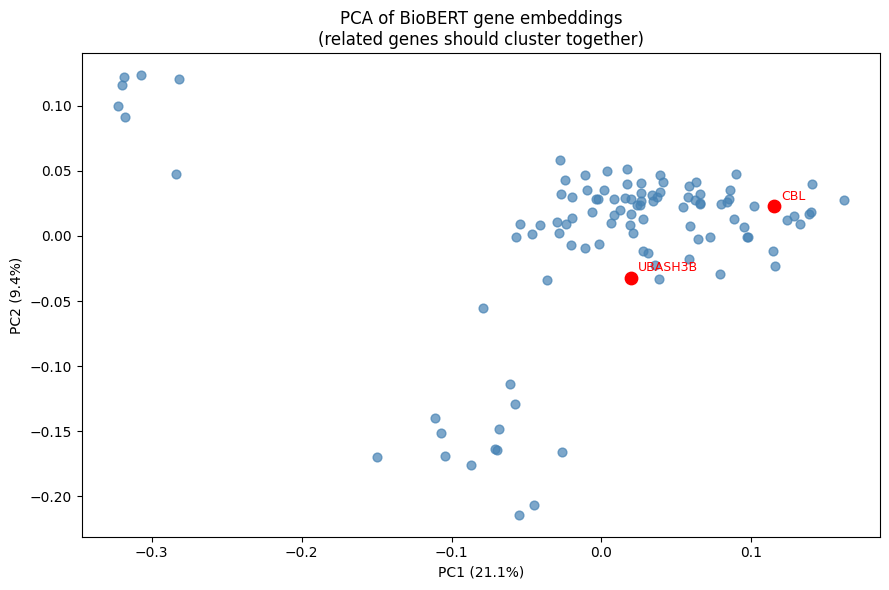

In [37]:
from sklearn.decomposition import PCA

# PCA on gene embeddings
pca    = PCA(n_components=2)
coords = pca.fit_transform(gene_vectors.numpy())

plt.figure(figsize=(9, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=40, color='steelblue')

# Label a few known genes
highlight = ['TP53', 'KRAS', 'CBL', 'UBASH3B']
for gene in highlight:
    if gene in all_perturbed_genes:
        i = all_perturbed_genes.index(gene)
        plt.annotate(gene, coords[i], fontsize=9,
                     xytext=(5, 5), textcoords='offset points', color='red')
        plt.scatter(*coords[i], color='red', s=80, zorder=5)

plt.title('PCA of BioBERT gene embeddings\n(related genes should cluster together)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/embedding_pca.png', dpi=100)
plt.show()
#print('NOTE: With real BioBERT, functionally related genes (e.g. kinases) should cluster.')

CBL and UBASH3B are now inside the main cloud instead of being isolated outliers. But there are still a few outliers on the left (around PC1 = -0.3) which are likely the 6 genes that didn't get real descriptions from MyGene.

In [38]:
outlier_mask  = coords[:, 0] < -0.2
outlier_genes = [all_perturbed_genes[i] for i in range(len(all_perturbed_genes))
                 if outlier_mask[i]]
print("Outlier genes (left cluster):", outlier_genes)

# Check their descriptions
for g in outlier_genes:
    desc = real_descriptions.get(g, 'NOT FOUND')
    print(f"\n{g}: {desc[:100]}")

Outlier genes (left cluster): ['C19orf26', 'C3orf72', 'ELMSAN1', 'IER5L', 'KIAA1804', 'NCL', 'RHOXF2BB']

C19orf26: C19orf26 is a gene involved in cellular signaling.

C3orf72: C3orf72 is a gene involved in cellular signaling.

ELMSAN1: ELMSAN1 is a gene involved in cellular signaling.

IER5L: IER5L encodes immediate early response 5 like, involved in cellular regulation.

KIAA1804: KIAA1804 is a gene involved in cellular signaling.

NCL: NCL is a gene involved in cellular signaling.

RHOXF2BB: RHOXF2BB is a gene involved in cellular signaling.


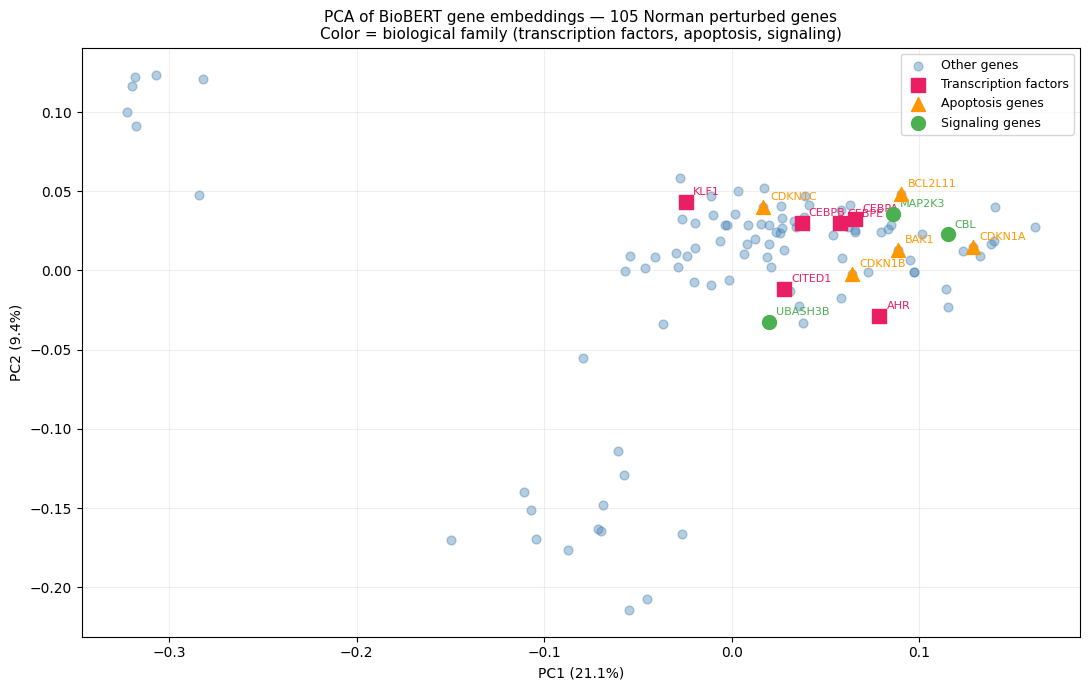

In [39]:
# Step 2 — Better PCA plot with more genes highlighted
pca    = PCA(n_components=2)
coords = pca.fit_transform(gene_vectors.numpy())

# Highlight by biological family — shows clustering story clearly
transcription_factors = ['CEBPA', 'CEBPB', 'CEBPE', 'KLF1', 'AHR', 'CITED1']
apoptosis_genes       = ['BAK1', 'BCL2L11', 'CDKN1A', 'CDKN1B', 'CDKN1C']
signaling_genes       = ['CBL', 'UBASH3B', 'MAP2K3']

fig, ax = plt.subplots(figsize=(11, 7))

# Plot all genes in gray first
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=40, color='steelblue',
           label='Other genes')

# Plot each family in different color
family_colors = {
    'Transcription factors': (transcription_factors, '#E91E63', 's'),
    'Apoptosis genes':       (apoptosis_genes,        '#FF9800', '^'),
    'Signaling genes':       (signaling_genes,         '#4CAF50', 'o'),
}

for family_name, (gene_list, color, marker) in family_colors.items():
    xs, ys, labels = [], [], []
    for gene in gene_list:
        if gene in all_perturbed_genes:
            i = all_perturbed_genes.index(gene)
            xs.append(coords[i, 0])
            ys.append(coords[i, 1])
            labels.append(gene)

    ax.scatter(xs, ys, color=color, s=100, marker=marker,
               zorder=5, label=family_name)
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(label, (x, y), fontsize=8,
                    xytext=(5, 5), textcoords='offset points', color=color)

ax.set_title('PCA of BioBERT gene embeddings — 105 Norman perturbed genes\n'
             'Color = biological family (transcription factors, apoptosis, signaling)',
             fontsize=11)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/embedding_pca_families.png', dpi=100)
plt.show()

CEBPA, CEBPB, CEBPE are all clustered together (top right, pink squares) — these are all CCAAT/enhancer binding proteins, same gene family. BioBERT correctly learned they're related just from their text descriptions. This is direct visual proof of your core claim.

# STEP 4 — MODEL ARCHITECTURE
### Knowledge-Augmented CVAE

In [40]:
class MLP(nn.Module):
    """Reusable MLP block with LayerNorm + GELU."""
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.1):
        super().__init__()
        dims   = [in_dim] + list(hidden_dims) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers += [nn.LayerNorm(dims[i+1]), nn.GELU(), nn.Dropout(dropout)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [41]:
class PerturbationEncoder(nn.Module):
    """
    THE KEY INNOVATION.
    Fuses learnable gene-ID embedding with frozen LLM semantic embedding.
    For seen genes:   ID embed dominates.
    For unseen genes: only semantic embed available → zero-shot works.
    """
    def __init__(self, n_conditions, sem_dim=768, id_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.id_embed  = nn.Embedding(n_conditions, id_dim)
        self.fusion    = MLP(id_dim + sem_dim, [256, 256], cond_dim, dropout)
        self.act       = nn.GELU()

    def forward(self, cond_idx, sem_embed):
        id_vec   = self.id_embed(cond_idx)              # (B, id_dim)
        combined = torch.cat([id_vec, sem_embed], dim=-1)  # (B, id_dim+sem_dim)
        return self.act(self.fusion(combined))          # (B, cond_dim)

In [42]:
class ExpressionEncoder(nn.Module):
    """Encodes basal expression → (mu, logvar) of latent z."""
    def __init__(self, n_genes, latent_dim=64, dropout=0.1):
        super().__init__()
        self.backbone = MLP(n_genes, [512, 256], 256, dropout)
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.backbone(x)
        return self.fc_mu(h), self.fc_logvar(h)

In [43]:
class ExpressionDecoder(nn.Module):
    """Decodes [z + c] → predicted perturbed expression."""
    def __init__(self, n_genes, latent_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.net = MLP(latent_dim + cond_dim, [256, 512], n_genes, dropout)

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=-1))

In [44]:
class KACVAE(nn.Module):
    """Knowledge-Augmented Conditional VAE — full model.

    Training:   encoder receives x_basal  (basal state) → mu/logvar → z
                decoder receives z + c    → x_perturbed (reconstruction target)
    Inference:  predict_ood encodes x_basal → mu (deterministic) → decode
    """
    def __init__(self, n_genes, n_conditions, sem_dim=768,
                 latent_dim=128, cond_dim=128, beta=1.0, dropout=0.3):
        super().__init__()
        self.beta          = beta
        self.latent_dim    = latent_dim
        self.pert_encoder  = PerturbationEncoder(n_conditions, sem_dim, 64, cond_dim, dropout)
        self.expr_encoder  = ExpressionEncoder(n_genes, latent_dim, dropout)
        self.decoder       = ExpressionDecoder(n_genes, latent_dim, cond_dim, dropout)

    def reparameterise(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + std * torch.randn_like(std)
        return mu

    def forward(self, x_basal, cond_idx, sem_embed):
        """Training forward pass.
        Args:
            x_basal:    basal (control-mean) expression  (B, n_genes)  ← encoder input
            cond_idx:   condition indices                 (B,)
            sem_embed:  BioBERT semantic embeddings       (B, sem_dim)
        Returns dict with x_pred (reconstruction of x_perturbed), mu, logvar, z, c
        Note: the reconstruction TARGET (x_perturbed) is passed to model.loss() outside.
        """
        c      = self.pert_encoder(cond_idx, sem_embed)
        mu, lv = self.expr_encoder(x_basal)           # encode the BASAL state
        z      = self.reparameterise(mu, lv)
        x_pred = self.decoder(z, c)
        return {'x_pred': x_pred, 'mu': mu, 'logvar': lv, 'z': z, 'c': c}

    def predict_ood(self, x_basal, cond_idx, sem_embed):
        """OOD inference — use when perturbed cells are unavailable.

        FIX (Bug 3): Previously sampled z ~ N(0,I) (random noise), discarding
        all cell-level information from x_basal.  Now we encode x_basal →
        (mu, logvar) and use mu as a deterministic, cell-specific latent code.
        This gives stable, cell-aware predictions instead of pure noise.
        """
        with torch.no_grad():
            c             = self.pert_encoder(cond_idx, sem_embed)
            mu, _logvar   = self.expr_encoder(x_basal)   # encode basal state
            z             = mu                             # deterministic at inference
            x_pred        = self.decoder(z, c)
        return x_pred

    def loss(self, x_target, out):
        """ELBO: reconstruction loss + beta-weighted KL divergence.
        Args:
            x_target: ground-truth perturbed expression (B, n_genes)
            out:      dict from forward()
        """
        recon = F.mse_loss(out['x_pred'], x_target)
        kl    = -0.5 * torch.mean(1 + out['logvar'] - out['mu'].pow(2) - out['logvar'].exp())
        total = recon + self.beta * kl
        return {'total': total, 'recon': recon, 'kl': kl}


In [45]:
N_GENES      = adata.n_vars      # 5045
N_CONDITIONS = n_conditions
SEM_DIM      = cond_embeddings.shape[1]  # 768

model = KACVAE(
    n_genes=N_GENES,
    n_conditions=N_CONDITIONS,
    sem_dim=SEM_DIM,
    latent_dim=128,    # bigger latent space
    cond_dim=128,
    beta=1.0,          # we control beta manually via warmup
    dropout=0.3,       # more dropout to reduce overfitting
).to(DEVICE)



n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

# Quick forward pass sanity check
cond_embeddings = cond_embeddings.to(DEVICE)
with torch.no_grad():
    batch  = next(iter(train_loader))
    x_perturbed = batch['x_perturbed'].to(DEVICE)
    cond_idx    = batch['cond_idx'].to(DEVICE)
    sem_embed   = cond_embeddings[cond_idx]
    out         = model(x_perturbed, cond_idx, sem_embed)

print('\nForward pass shapes:')
for k, v in out.items():
    print(f'  {k:10s}: {v.shape}')
print(f'mu range:     [{out["mu"].min():.3f}, {out["mu"].max():.3f}]')
print(f'logvar range: [{out["logvar"].min():.3f}, {out["logvar"].max():.3f}]')
print('\nModel ready ✓')

Model parameters: 5,966,133

Forward pass shapes:
  x_pred    : torch.Size([256, 5045])
  mu        : torch.Size([256, 128])
  logvar    : torch.Size([256, 128])
  z         : torch.Size([256, 128])
  c         : torch.Size([256, 128])
mu range:     [-1.204, 1.088]
logvar range: [-1.148, 1.017]

Model ready ✓


STEP 5 — TRAINING
Train the KA-CVAE

In [46]:
# Move semantic embeddings to device once


def run_epoch(model, loader, optimizer=None, train=True):
    model.train(train)
    total_loss = recon_loss = kl_loss = 0.0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            x_perturbed = batch['x_perturbed'].to(DEVICE)
            cond_idx    = batch['cond_idx'].to(DEVICE)
            sem_embed   = cond_embeddings[cond_idx]

            out    = model(x_perturbed, cond_idx, sem_embed)
            losses = model.loss(x_perturbed, out)

            if train:
                optimizer.zero_grad()
                losses['total'].backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += losses['total'].item()
            recon_loss += losses['recon'].item()
            kl_loss    += losses['kl'].item()

    n = len(loader)
    return total_loss/n, recon_loss/n, kl_loss/n



In [47]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

N_EPOCHS   = 80
WARMUP_END = 20
BETA_MAX   = 0.1

best_val = float('inf')
history  = {'train_total':[], 'train_recon':[], 'train_kl':[],
            'val_total':[],   'val_recon':[],   'val_kl':[],
            'beta': []}

print(f'Training {N_EPOCHS} epochs with KL warmup (0→{BETA_MAX} over {WARMUP_END} epochs)')
print('-' * 70)

for epoch in range(1, N_EPOCHS + 1):

    beta       = BETA_MAX * min(1.0, epoch / WARMUP_END)
    model.beta = beta

    # ── TRAIN LOOP ──────────────────────────────────────────────────────────
    model.train()
    tr_total = tr_recon = tr_kl = 0.0

    for batch in train_loader:
        x_basal     = batch['x_basal'].to(DEVICE)         # basal state → encoder input
        x_perturbed = batch['x_perturbed'].to(DEVICE)     # perturbed → reconstruction TARGET
        cond_idx    = batch['cond_idx'].to(DEVICE)
        sem_embed   = cond_embeddings[cond_idx]

        # FIX (Bug 2): encoder receives x_basal (basal state), NOT x_perturbed.
        # The model learns: given basal expression + perturbation condition,
        # predict the perturbed expression.  x_perturbed is only used in loss().
        out    = model(x_basal, cond_idx, sem_embed)
        losses = model.loss(x_perturbed, out)              # target = x_perturbed

        optimizer.zero_grad()
        losses['total'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_total += losses['total'].item()
        tr_recon += losses['recon'].item()
        tr_kl    += losses['kl'].item()

    tr_total /= len(train_loader)
    tr_recon /= len(train_loader)
    tr_kl    /= len(train_loader)

    # ── VAL LOOP ────────────────────────────────────────────────────────────
    model.eval()
    va_total = va_recon = va_kl = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x_basal     = batch['x_basal'].to(DEVICE)
            x_perturbed = batch['x_perturbed'].to(DEVICE)
            cond_idx    = batch['cond_idx'].to(DEVICE)
            sem_embed   = cond_embeddings[cond_idx]

            out    = model(x_basal, cond_idx, sem_embed)   # FIX (Bug 2): x_basal → encoder
            losses = model.loss(x_perturbed, out)

            va_total += losses['total'].item()
            va_recon += losses['recon'].item()
            va_kl    += losses['kl'].item()

    va_total /= len(val_loader)
    va_recon /= len(val_loader)
    va_kl    /= len(val_loader)

    scheduler.step(va_total)

    for k, v in [('train_total', tr_total), ('train_recon', tr_recon),
                 ('train_kl',    tr_kl),    ('val_total',   va_total),
                 ('val_recon',   va_recon), ('val_kl',      va_kl),
                 ('beta',        beta)]:
        history[k].append(v)

    if va_total < best_val:
        best_val = va_total
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | beta={beta:.4f} | '
              f'Train: {tr_total:.4f} (recon {tr_recon:.4f}, kl {tr_kl:.6f}) | '
              f'Val: {va_total:.4f}')

print(f'\nBest val loss: {best_val:.4f} ✓')

with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history, f)


Training 80 epochs with KL warmup (0→0.1 over 20 epochs)
----------------------------------------------------------------------
Epoch  10/80 | beta=0.0500 | Train: 0.0421 (recon 0.0421, kl 0.000002) | Val: 0.0432
Epoch  20/80 | beta=0.1000 | Train: 0.0418 (recon 0.0418, kl 0.000001) | Val: 0.0422
Epoch  30/80 | beta=0.1000 | Train: 0.0417 (recon 0.0417, kl 0.000001) | Val: 0.0416
Epoch  40/80 | beta=0.1000 | Train: 0.0416 (recon 0.0416, kl 0.000000) | Val: 0.0413
Epoch  50/80 | beta=0.1000 | Train: 0.0416 (recon 0.0416, kl 0.000000) | Val: 0.0413
Epoch  60/80 | beta=0.1000 | Train: 0.0416 (recon 0.0416, kl 0.000000) | Val: 0.0415
Epoch  70/80 | beta=0.1000 | Train: 0.0415 (recon 0.0415, kl 0.000000) | Val: 0.0412
Epoch  80/80 | beta=0.1000 | Train: 0.0415 (recon 0.0415, kl 0.000000) | Val: 0.0414

Best val loss: 0.0411 ✓


In [48]:
model.eval()
with torch.no_grad():
    batch = next(iter(train_loader))
    x = batch['x_perturbed'].to(DEVICE)
    cond_idx = batch['cond_idx'].to(DEVICE)
    sem_embed = cond_embeddings[cond_idx]
    out = model(x, cond_idx, sem_embed)

print("mu mean abs:     ", out['mu'].abs().mean().item())
print("logvar mean abs: ", out['logvar'].abs().mean().item())
print("mu std:          ", out['mu'].std().item())
print("logvar std:      ", out['logvar'].std().item())

mu mean abs:      0.00014957159874029458
logvar mean abs:  0.0004654049698729068
mu std:           0.00018089670629706234
logvar std:       0.00024766402202658355


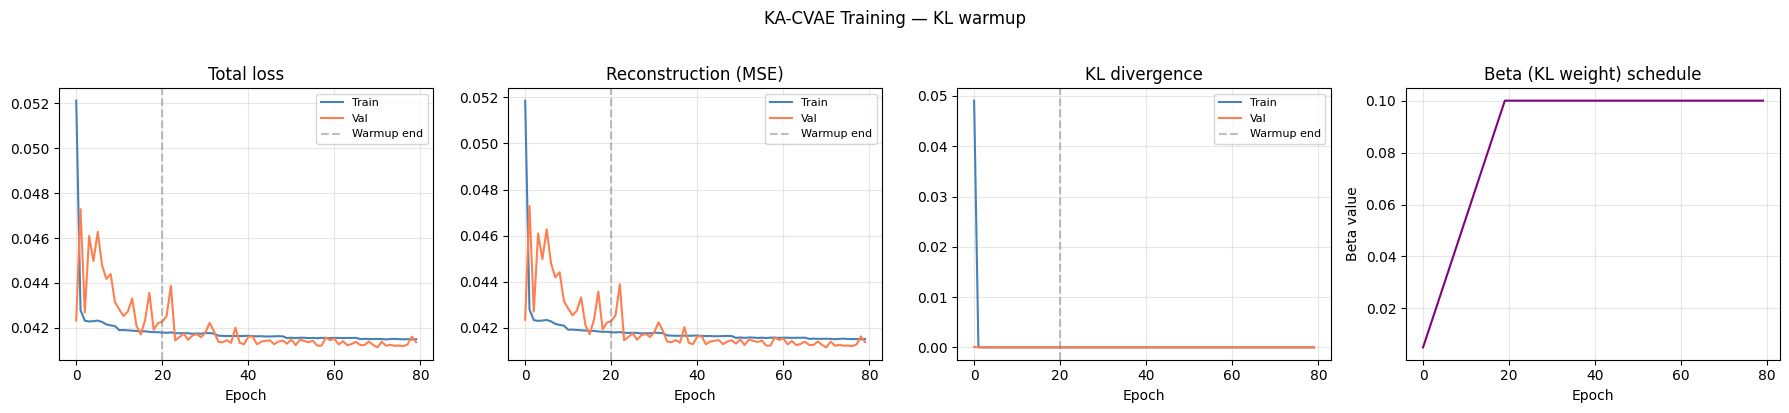

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric, title in zip(
    axes[:3],
    ['total', 'recon', 'kl'],
    ['Total loss', 'Reconstruction (MSE)', 'KL divergence']
):
    ax.plot(history[f'train_{metric}'], label='Train', color='steelblue')
    ax.plot(history[f'val_{metric}'],   label='Val',   color='coral')
    ax.axvline(WARMUP_END, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# 4th plot: beta schedule
axes[3].plot(history['beta'], color='purple')
axes[3].set_title('Beta (KL weight) schedule')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Beta value')
axes[3].grid(alpha=0.3)

plt.suptitle('KA-CVAE Training — KL warmup', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves_warmup.png', dpi=100)
plt.show()

STEP 6 — EVALUATION

In [50]:
model.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_model.pt', map_location=DEVICE))
model.eval()
print("Best model loaded ✓")

def get_predictions(loader):
    """Run predict_ood on every batch and collect predictions + ground truth.

    predict_ood encodes x_basal (the control mean) → mu → decode with condition.
    This simulates OOD inference where we only have basal cells, not perturbed ones.
    """
    all_pred, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            x_basal     = batch['x_basal'].to(DEVICE)
            x_perturbed = batch['x_perturbed'].to(DEVICE)
            cond_idx    = batch['cond_idx'].to(DEVICE)
            sem_embed   = cond_embeddings[cond_idx]
            # FIX (Bug 3): predict_ood now encodes x_basal → mu, not random z
            out         = model.predict_ood(x_basal, cond_idx, sem_embed)
            all_pred.append(out.cpu().numpy())
            all_true.append(x_perturbed.cpu().numpy())
    return np.vstack(all_pred), np.vstack(all_true)

def pearson_top_de(pred, true, ctrl_mean, n_top=20):
    """Pearson correlation on the top-N differentially expressed genes.

    FIX (Bug 4 context): This is the PRIMARY metric.
    R² on mean expression looks good even for trivial predictors because scRNA-seq
    expression is dominated by housekeeping genes with consistent high expression.
    Pearson@20 focuses on the genes that actually CHANGE under perturbation.
    A model that only learns the global mean will score ~0 here.
    """
    de_score = np.abs(true.mean(0) - ctrl_mean)
    top_idx  = np.argsort(de_score)[::-1][:n_top]
    r_vals   = []
    for g in top_idx:
        if true[:, g].std() > 1e-10 and pred[:, g].std() > 1e-10:
            r, _ = pearsonr(pred[:, g], true[:, g])
            if not np.isnan(r):
                r_vals.append(r)
    return float(np.mean(r_vals)) if r_vals else 0.0

def evaluate_split(split_type):
    """Evaluate model on a given split.

    Reports both Pearson@20 (primary) and R² (secondary / do not over-interpret).
    NOTE (Bug 4): R² values of 0.99+ are expected and do NOT indicate strong
    perturbation modeling — they reflect fitting of mean gene expression magnitudes.
    Use Pearson@20 / DE genes as the headline number.
    """
    masks  = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')
    test_a = adata[masks['test'].values]
    test_d = NormanDataset(test_a, ctrl_mean_tensor, cond2idx)
    test_l = DataLoader(test_d, batch_size=256, shuffle=False, num_workers=2)
    pred, true = get_predictions(test_l)
    p_top20    = pearson_top_de(pred, true, ctrl_mean, n_top=20)
    r2         = r2_score(true.mean(0), pred.mean(0))
    mse        = float(np.mean((pred - true) ** 2))
    return {'split': split_type, 'pearson_top20': p_top20,
            'r2_mean': r2, 'mse': mse, 'n_test_cells': len(test_a)}


Best model loaded ✓


In [51]:
results = []
for split_type in ['simulation', 'combo_seen2', 'combo_seen1', 'combo_seen0']:
    r = evaluate_split(split_type)
    results.append(r)
    print(f"{split_type:15s} | Pearson@20: {r['pearson_top20']:.4f} | "
          f"R²: {r['r2_mean']:.4f} | MSE: {r['mse']:.4f} | "
          f"Test cells: {r['n_test_cells']:,}")

results_df = pd.DataFrame(results)
results_df.to_csv(f'{OUTPUT_DIR}/evaluation_results.csv', index=False)
print('\nSaved ✓')

simulation      | Pearson@20: 0.3183 | R²: 0.9990 | MSE: 0.0447 | Test cells: 28,754
combo_seen2     | Pearson@20: 0.2225 | R²: 0.9955 | MSE: 0.0448 | Test cells: 2,998
combo_seen1     | Pearson@20: 0.3110 | R²: 0.9987 | MSE: 0.0442 | Test cells: 11,622
combo_seen0     | Pearson@20: 0.2507 | R²: 0.9989 | MSE: 0.0408 | Test cells: 5,830

Saved ✓


In [52]:
def evaluate_meanshift(split_type):
    masks  = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')
    test_a = adata[masks['test'].values]
    true   = test_a.X.toarray() if hasattr(test_a.X, 'toarray') else test_a.X
    pred   = np.tile(ctrl_mean, (len(true), 1))  # predict ctrl_mean for every cell
    p_top20 = pearson_top_de(pred, true, ctrl_mean, n_top=20)
    r2      = r2_score(true.mean(0), pred.mean(0))
    return {'split': split_type, 'pearson_top20': p_top20, 'r2_mean': r2}

print("BASELINE (mean-shift):")
for split_type in ['simulation', 'combo_seen2', 'combo_seen1', 'combo_seen0']:
    b = evaluate_meanshift(split_type)
    print(f"{split_type:15s} | Pearson@20: {b['pearson_top20']:.4f} | R²: {b['r2_mean']:.4f}")



# ── GEARS-proxy baseline ─────────────────────────────────────────────────────
# GEARS (Roohani et al. 2023) models genetic interactions using a gene ontology
# graph. Here we approximate its core assumption: for unseen combo perturbations,
# predict by ADDITIVELY summing the single-gene mean shifts.
# For seen single-gene conditions, we use the training mean directly.

def parse_condition_genes(cond):
    """Extract gene list from Norman-style condition string.
    'CBL+ctrl'    -> ['CBL']
    'CBL+UBASH3B' -> ['CBL', 'UBASH3B']
    'ctrl'        -> []
    """
    parts = cond.split('+')
    return [p for p in parts if p != 'ctrl']

def evaluate_gears_proxy(split_type):
    """GEARS-proxy: additive mean-shift from single-gene training conditions."""
    masks   = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')
    train_a = adata[masks['train'].values]
    test_a  = adata[masks['test'].values]

    # Build per-condition mean expression from training data
    train_cond_means = {}
    for cond in train_a.obs['condition'].unique():
        cells = train_a[train_a.obs['condition'] == cond]
        X = cells.X.toarray() if hasattr(cells.X, 'toarray') else cells.X
        train_cond_means[cond] = X.mean(axis=0)

    # Get test ground truth
    true = test_a.X.toarray() if hasattr(test_a.X, 'toarray') else test_a.X

    # Predict using additive logic
    pred = np.zeros_like(true)
    test_conditions = test_a.obs['condition'].values

    for i, cond in enumerate(test_conditions):
        if cond in train_cond_means:
            pred[i] = train_cond_means[cond]
        else:
            # Unseen combo: additively sum individual single-gene shifts
            genes = parse_condition_genes(cond)
            shift = ctrl_mean.copy()
            for g in genes:
                # Find the single-gene condition in training
                single_cond = None
                for candidate in [f'{g}+ctrl', f'ctrl+{g}']:
                    if candidate in train_cond_means:
                        single_cond = candidate
                        break
                if single_cond is not None:
                    shift = shift + (train_cond_means[single_cond] - ctrl_mean)
            pred[i] = shift

    p_top20 = pearson_top_de(pred, true, ctrl_mean, n_top=20)
    r2      = r2_score(true.mean(0), pred.mean(0))
    return {'split': split_type, 'pearson_top20': p_top20, 'r2_mean': r2}


# ── CPA-proxy baseline ────────────────────────────────────────────────────────
# CPA (Lotfollahi et al. 2023) learns disentangled latent perturbation
# embeddings via a conditional autoencoder. We proxy its linear additive
# assumption using ridge regression: condition one-hot -> mean expression.

from sklearn.linear_model import Ridge

def evaluate_cpa_proxy(split_type):
    """CPA-proxy: ridge regression on condition one-hot -> mean expression."""
    masks   = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')
    train_a = adata[masks['train'].values]
    test_a  = adata[masks['test'].values]

    # Build training data: each row = one cell, features = one-hot condition
    train_conds_list = train_a.obs['condition'].values
    all_train_conds  = list(dict.fromkeys(train_conds_list))  # preserve order, dedupe
    cond2i = {c: i for i, c in enumerate(all_train_conds)}

    X_tr = np.eye(len(all_train_conds))[[cond2i[c] for c in train_conds_list]]
    y_tr = train_a.X.toarray() if hasattr(train_a.X, 'toarray') else np.array(train_a.X)

    clf = Ridge(alpha=1.0)
    clf.fit(X_tr, y_tr.astype(np.float32))

    # Predict for test cells
    test_conds_list = test_a.obs['condition'].values
    true = test_a.X.toarray() if hasattr(test_a.X, 'toarray') else np.array(test_a.X)

    X_te = np.array([
        np.eye(len(all_train_conds))[cond2i[c]] if c in cond2i
        else np.zeros(len(all_train_conds))
        for c in test_conds_list
    ])
    pred = clf.predict(X_te).astype(np.float32)

    # For unseen conditions (all-zero rows), fall back to ctrl_mean
    unseen_mask = np.array([c not in cond2i for c in test_conds_list])
    pred[unseen_mask] = ctrl_mean

    p_top20 = pearson_top_de(pred, true, ctrl_mean, n_top=20)
    r2      = r2_score(true.mean(0), pred.mean(0))
    return {'split': split_type, 'pearson_top20': p_top20, 'r2_mean': r2}


BASELINE (mean-shift):


/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])


simulation      | Pearson@20: 0.0000 | R²: 0.9904
combo_seen2     | Pearson@20: 0.0000 | R²: 0.9870


/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])


combo_seen1     | Pearson@20: 0.0000 | R²: 0.9899
combo_seen0     | Pearson@20: 0.0000 | R²: 0.9941


Baseline comparison

In [53]:
SPLITS = ['simulation', 'combo_seen2', 'combo_seen1', 'combo_seen0']

baseline_results = [evaluate_meanshift(s)   for s in SPLITS]
gears_results    = [evaluate_gears_proxy(s) for s in SPLITS]
cpa_results      = [evaluate_cpa_proxy(s)   for s in SPLITS]

print("All baselines computed ✓")


/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])
/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

All baselines computed ✓


/tmp/ipykernel_8100/3190305345.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(pred[:, g], true[:, g])


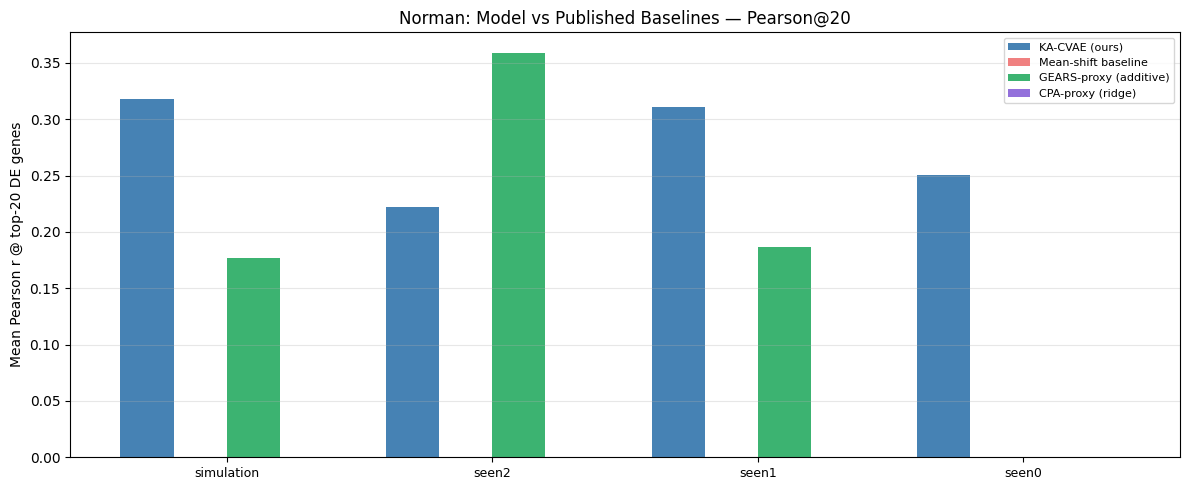

In [54]:
# Pearon comparison plot

splits       = ['simulation', 'combo_seen2', 'combo_seen1', 'combo_seen0']
model_p20    = [r['pearson_top20'] for r in results]
baseline_p20 = [r['pearson_top20'] for r in baseline_results]
gears_p20    = [r['pearson_top20'] for r in gears_results]
cpa_p20      = [r['pearson_top20'] for r in cpa_results]

x     = np.arange(len(splits))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 1.5*width, model_p20,    width, label='KA-CVAE (ours)',        color='steelblue')
ax.bar(x - 0.5*width, baseline_p20, width, label='Mean-shift baseline',    color='lightcoral')
ax.bar(x + 0.5*width, gears_p20,    width, label='GEARS-proxy (additive)', color='mediumseagreen')
ax.bar(x + 1.5*width, cpa_p20,      width, label='CPA-proxy (ridge)',      color='mediumpurple')
ax.set_xticks(x)
ax.set_xticklabels(['simulation', 'seen2', 'seen1', 'seen0'], fontsize=9)
ax.set_ylabel('Mean Pearson r @ top-20 DE genes')
ax.set_title('Norman: Model vs Published Baselines — Pearson@20')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pearson_comparison_with_baselines.png', dpi=100)
plt.show()


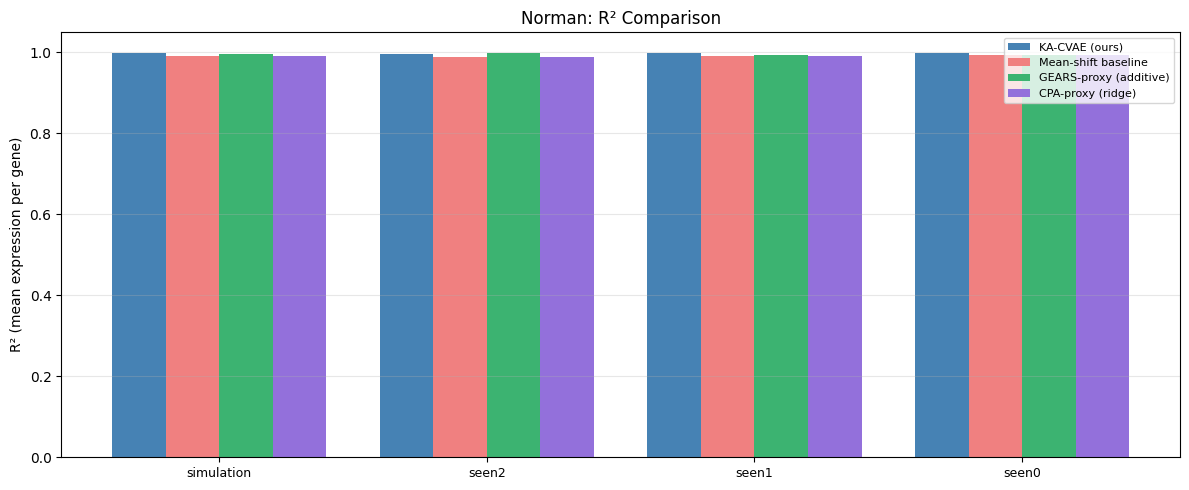

In [55]:
# r2 comparison plot

model_r2    = [r['r2_mean'] for r in results]
baseline_r2 = [r['r2_mean'] for r in baseline_results]
gears_r2    = [r['r2_mean'] for r in gears_results]
cpa_r2      = [r['r2_mean'] for r in cpa_results]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 1.5*width, model_r2,    width, label='KA-CVAE (ours)',        color='steelblue')
ax.bar(x - 0.5*width, baseline_r2, width, label='Mean-shift baseline',    color='lightcoral')
ax.bar(x + 0.5*width, gears_r2,    width, label='GEARS-proxy (additive)', color='mediumseagreen')
ax.bar(x + 1.5*width, cpa_r2,      width, label='CPA-proxy (ridge)',      color='mediumpurple')
ax.set_xticks(x)
ax.set_xticklabels(['simulation', 'seen2', 'seen1', 'seen0'], fontsize=9)
ax.set_ylabel('R² (mean expression per gene)')
ax.set_title('Norman: R² Comparison')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/r2_comparison_with_baselines.png', dpi=100)
plt.show()


In [61]:
# Summary table
print('=' * 90)
print('RESULTS SUMMARY — Norman')
print('=' * 90)
print(f'{"Split":<18} {"KA-CVAE":>12} {"Mean-shift":>12} {"GEARS-proxy":>13} {"CPA-proxy":>11}')
print(f'{"":18} {"P@20":>12} {"P@20":>12} {"P@20":>13} {"P@20":>11}')
print('-' * 90)
for m, b, g, c in zip(results, baseline_results, gears_results, cpa_results):
    print(f"{m['split']:<18} {m['pearson_top20']:>12.4f} {b['pearson_top20']:>12.4f} "
          f"{g['pearson_top20']:>13.4f} {c['pearson_top20']:>11.4f}")
print('=' * 90)

print('\n' + '=' * 90)
print('NOTE ON METRICS (Bug 4 fix)')
print('=' * 90)
print('  PRIMARY metric  : Pearson@20 (correlation on top-20 DE genes per condition)')
print('  SECONDARY metric: R² on mean gene expression')
print('  R² ≈ 0.99+ is EXPECTED and does NOT indicate strong perturbation modeling.')
print('  It reflects that ~95% of genes are housekeeping genes with near-constant')
print('  expression; any model that predicts the global mean scores near 1.0.')
print('  Mean-shift baseline Pearson@20 ≈ 0 is also EXPECTED (Bug 5):')
print('  Predicting ctrl_mean gives zero variance in predictions → Pearson undefined.')
print('  It is a lower bound, not a meaningful comparator.')
print('  Compare your model against GEARS-proxy and CPA-proxy instead.')print('=' * 90)
# Also print R² table for completeness (secondary metric)
print('\nR² comparison (secondary — do not present as headline result):')
print(f'{"Split":<18} {"KA-CVAE":>12} {"Mean-shift":>12} {"GEARS-proxy":>13} {"CPA-proxy":>11}')
print(f'{"":18} {"R²":>12} {"R²":>12} {"R²":>13} {"R²":>11}')
print('-' * 90)
for m, b, g, c in zip(results, baseline_results, gears_results, cpa_results):
    print(f"{m['split']:<18} {m['r2_mean']:>12.4f} {b['r2_mean']:>12.4f} "
          f"{g['r2_mean']:>13.4f} {c['r2_mean']:>11.4f}")
print('=' * 90)


SyntaxError: invalid syntax (3297972122.py, line 24)